# 04 — Temporal Analysis: Multi-Decadal Trajectories, Seasonality & Persistence
**Project:** AI-Based Urban Change & Environmental Risk Intelligence for Chittoor District, AP  
**Stage:** Longitudinal & Time-Series Analytics  

### Objectives:
1. Deconstruct multi-annual trends and interannual variations across Chittoor District.
2. Evaluate lag autocorrelation structures (AR-1, AR-2) to distinguish persistent trends (built-up) from oscillatory climate noise (NDVI, LST, rainfall).
3. Analyze the physical inertia of land-use change versus meteorologically forced indicators.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(project_root))

df = pd.read_csv(project_root / "data" / "processed" / "Chittoor_Master_Research_Dataset_2016_2025.csv")
df.sort_values("year", inplace=True)
df.reset_index(drop=True, inplace=True)

## 1. Lag Autocorrelation Analysis
Compute Lag-1 autocorrelation ($r_{t, t-1}$) across all indicators to measure temporal memory.

In [2]:
lag_results = []
for col in ["built_up_km2", "strong_built_up_km2", "NDVI", "LST_C", "rainfall_mm", "environmental_stress"]:
    s = df[col]
    autocorr_1 = s.autocorr(lag=1)
    autocorr_2 = s.autocorr(lag=2)
    lag_results.append({
        "Indicator": col,
        "Lag-1 Autocorr (r)": round(autocorr_1, 4),
        "Lag-2 Autocorr (r)": round(autocorr_2, 4),
        "Temporal Nature": "Secular / Inertial (Predictable)" if autocorr_1 > 0.8 else "Oscillatory / Stochastic (Low Predictability)"
    })

pd.DataFrame(lag_results)

,Indicator,Lag-1 Autocorr (r),Lag-2 Autocorr (r),Temporal Nature
0,built_up_km2,0.9563,0.9197,Secular / Inertial (Predictable)
1,strong_built_up_km2,0.9735,0.9733,Secular / Inertial (Predictable)
2,NDVI,-0.0958,0.0443,Oscillatory / Stochastic (Low Predictability)
3,LST_C,0.6961,0.4879,Oscillatory / Stochastic (Low Predictability)
4,rainfall_mm,0.2621,0.3600,Oscillatory / Stochastic (Low Predictability)
5,environmental_stress,0.2252,-0.4695,Oscillatory / Stochastic (Low Predictability)


## 2. Linear Secular Trend Fitting & Residual Analysis
Fit OLS linear models over time to determine annual expansion rates.

In [3]:
X = sm.add_constant(df["year"])

# Built-Up Trend
model_bu = sm.OLS(df["built_up_km2"], X).fit()
# Strong Core Trend
model_core = sm.OLS(df["strong_built_up_km2"], X).fit()

print("=== Built-Up Extent Secular Trend Model ===")
print(f"Annual Growth Rate: +{model_bu.params['year']:.2f} km²/year (p = {model_bu.pvalues['year']:.4e}, R² = {model_bu.rsquared:.4f})")
print(f"=== Strong Built-Up Core Trend Model ===")
print(f"Annual Growth Rate: +{model_core.params['year']:.2f} km²/year (p = {model_core.pvalues['year']:.4e}, R² = {model_core.rsquared:.4f})")

=== Built-Up Extent Secular Trend Model ===
Annual Growth Rate: +11.09 km²/year (p = 7.0905e-07, R² = 0.9600)
=== Strong Built-Up Core Trend Model ===
Annual Growth Rate: +3.51 km²/year (p = 2.3013e-07, R² = 0.9698)


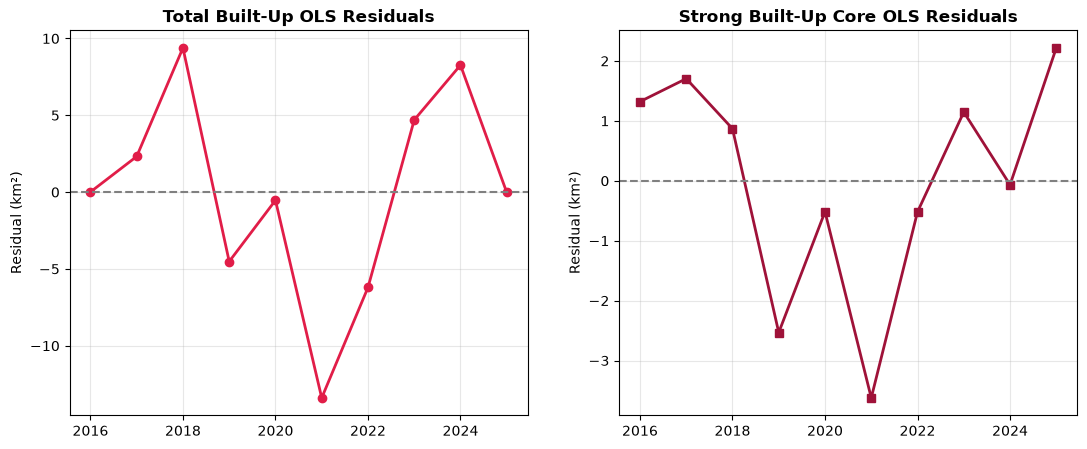

In [4]:
# Residual Diagnostics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(df["year"], model_bu.resid, marker="o", color="#e11d48", lw=2)
ax1.axhline(0, color="gray", linestyle="--")
ax1.set_title("Total Built-Up OLS Residuals", fontweight="bold")
ax1.set_ylabel("Residual (km²)")
ax1.grid(True, alpha=0.3)

ax2.plot(df["year"], model_core.resid, marker="s", color="#9f1239", lw=2)
ax2.axhline(0, color="gray", linestyle="--")
ax2.set_title("Strong Built-Up Core OLS Residuals", fontweight="bold")
ax2.set_ylabel("Residual (km²)")
ax2.grid(True, alpha=0.3)

plt.show()